In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00a 0:00:01


In [ ]:
from ultralytics import YOLO
import torch
import os
import matplotlib.pyplot as plt
import cv2
from IPython.display import display, Image

In [27]:
# ============================================================
# CHECK GPU AVAILABILITY
# ============================================================
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: Tesla T4


In [28]:
# ============================================================
# DATASET PATH
# ============================================================
DATASET_PATH = "/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data"

print("Dataset folders found:", os.listdir(DATASET_PATH))

Dataset folders found: ['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train']


In [29]:
# ============================================================
# CREATE data.yaml
# ============================================================
yaml_content = """
path: /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data

train: train/images
val: valid/images
test: test/images

names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Cone
  7: Safety Vest
  8: machinery
  9: vehicle
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml successfully created in /kaggle/working/!")

data.yaml successfully created in /kaggle/working/!


In [30]:
# ============================================================
# LOAD YOLOv8s MODEL
# ============================================================
model = YOLO("yolov8s.pt")

In [31]:
# ============================================================
# TRAIN MODEL (Optimized for Higher Recall on Safety Violations)
# ============================================================
results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,                  # Increased to give the model more time to adapt to difficult classes
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    optimizer="AdamW",
    lr0=0.005,                  # Lowered from 0.01 to stabilize fine-tuning of negative classes
    patience=10,               
    project="construction_safety_project",
    name="yolov8s_run",
    cache=False,                # Suppresses Kaggle's read-only directory warnings
    
    # --- Weighting & Loss Tweaks ---
    cls=1.5,                    # Tripled classification focus (default is 0.5) to aggressively fix recall
    
    # --- Advanced Augmentations ---
    mosaic=1.0,                 # High mosaic for complex clustered scenes
    mixup=0.15,                 # Blends images to assist with occluded vehicles/machinery
    scale=0.6                   # Multi-scale variance optimization
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_run-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=

In [32]:
# ============================================================
# VALIDATE MODEL
# ============================================================
metrics = model.val()

print("Validation mAP50:", metrics.results_dict.get('metrics/mAP50(B)'))
print("Validation Recall:", metrics.results_dict.get('metrics/recall(B)'))

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 2.5±0.4 ms, read: 44.7±17.3 MB/s, size: 59.5 KB)
val: Scanning /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid/labels... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 413.8it/s 0.3ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.3it/s 3.5s0.3ss
                   all        114        697      0.882      0.704      0.775      0.442
               Hardhat         42         79      0.968      0.772      0.854      0.512
                  Mask         19         21      0.897      0.827      0.881

--- Found Confusion Matrix at /kaggle/working/runs/detect/val-3/confusion_matrix.png ---


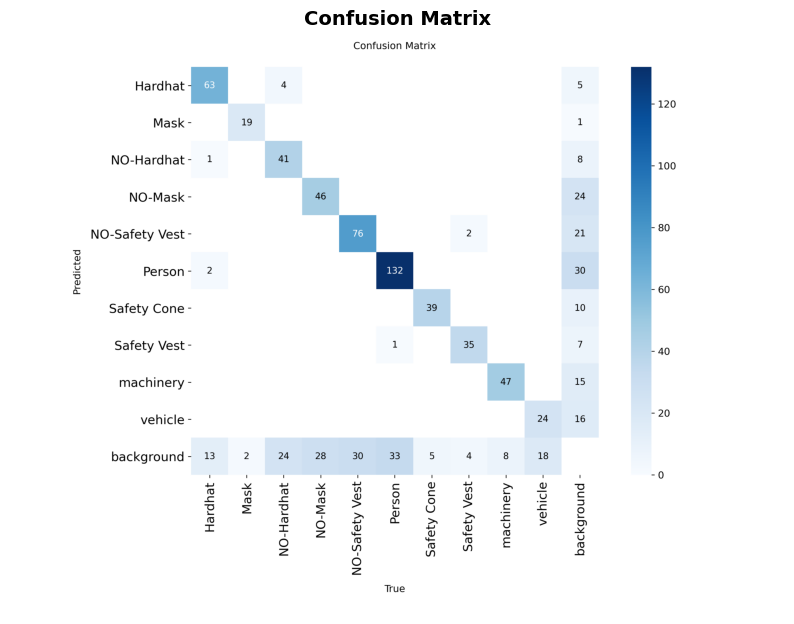


📊 GENERATING PRECISION-RECALL CURVE FROM METRICS


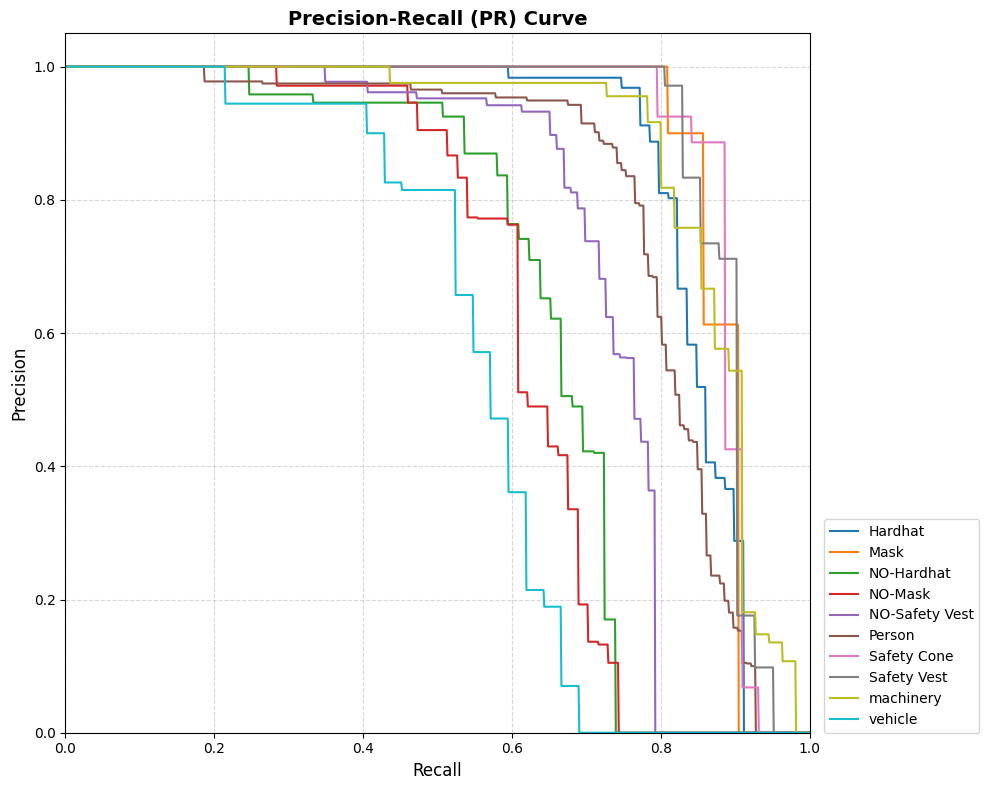


📊 GENERATING F1-CONFIDENCE CURVE FROM METRICS


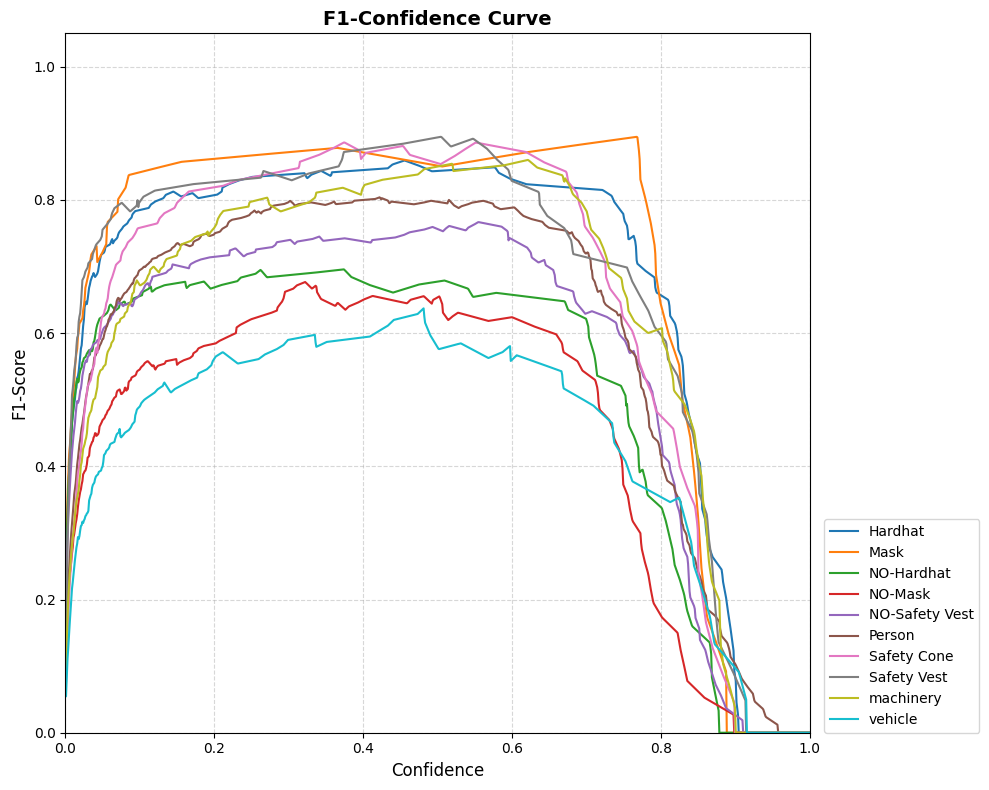

In [35]:
import numpy as np

# ------------------------------------------------------------
# 1. DISPLAY GENERATED CONFUSION MATRIX (From Saved File)
# ------------------------------------------------------------
val_dir = "/kaggle/working/runs/detect"
target_dir = None

if os.path.exists(val_dir):
    val_folders = sorted([f for f in os.listdir(val_dir) if f.startswith('val')])
    if val_folders:
        target_dir = os.path.join(val_dir, val_folders[-1])

if target_dir:
    for fname in ["confusion_matrix.png", "Confusion_Matrix.png", "confusion_matrix_normalized.png"]:
        matrix_path = os.path.join(target_dir, fname)
        if os.path.exists(matrix_path):
            print(f"--- Found Confusion Matrix at {matrix_path} ---")
            img = cv2.imread(matrix_path)
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
            plt.show()
            break

# ------------------------------------------------------------
# 2. GENERATE PRECISION-RECALL CURVE FROM MEMORY METRICS
# ------------------------------------------------------------
print(f"\n{'='*60}\n📊 GENERATING PRECISION-RECALL CURVE FROM METRICS\n{'='*60}")

plt.figure(figsize=(10, 8))

# Extract names from metrics object mapping indices to text labels
class_names = metrics.names

# Parse precision and recall curve data from memory array structures
# YOLO curves data layout: curves_results[0] handles the global PR tracking matrices
pr_data = metrics.curves_results[0]
recall_vals = pr_data[0]       # Universal X-axis array range [0.0 to 1.0]
precision_matrix = pr_data[1]  # Y-axis data array matrix per class index

for class_idx in range(precision_matrix.shape[0]):
    label = class_names.get(class_idx, f"Class {class_idx}")
    plt.plot(recall_vals, precision_matrix[class_idx], label=f"{label}")

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall (PR) Curve", fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", bbox_to_anchor=(1.02, 0), borderaxespad=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. GENERATE F1-CONFIDENCE CURVE FROM MEMORY METRICS
# ------------------------------------------------------------
print(f"\n{'='*60}\n📊 GENERATING F1-CONFIDENCE CURVE FROM METRICS\n{'='*60}")

plt.figure(figsize=(10, 8))

# curves_results[1] contains the system F1 curve evaluations mapping
f1_data = metrics.curves_results[1]
conf_vals = f1_data[0]    # Universal Confidence levels mapping interval [0.0 to 1.0]
f1_matrix = f1_data[1]    # Extracted scalar F1 arrays matching classes coordinates

for class_idx in range(f1_matrix.shape[0]):
    label = class_names.get(class_idx, f"Class {class_idx}")
    plt.plot(conf_vals, f1_matrix[class_idx], label=f"{label}")

plt.xlabel("Confidence", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.title("F1-Confidence Curve", fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", bbox_to_anchor=(1.02, 0), borderaxespad=0)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# RUN DETECTION ON TEST IMAGES
# ============================================================
results = model.predict(
    source="/kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/test/images",
    conf=0.35,
    save=True
)


image 1/82 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 1 Hardhat, 1 Person, 16.2ms
image 2/82 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 2 NO-Masks, 1 NO-Safety Vest, 5 Persons, 16.3ms
image 3/82 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 2 NO-Safety Vests, 2 Persons, 16.1ms
image 4/82 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/css-data/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg: 640x640 1 Hardhat, 2 NO-Safety Vests, 1 Person, 1 Safety Cone, 16.1ms
image 5/82 /kaggle/input/datasets/snehilsanyal/construction-site-safety-image-dataset-robofl

Total Prediction Images: 82
First 5 files: ['IMG_3103_mp4-9_jpg.rf.b31bd2d816465a27aa1eb072f90bb5aa.jpg', 'youtube-152_jpg.rf.9147878e3ddda845e58f7d9c041f1338.jpg', 'construction-2-_mp4-162_jpg.rf.efad5f15524c736fe03b9c9936adc481.jpg', 'construction-1159-_jpg.rf.9f3172102a34edb157b556a73931c831.jpg', 'IMG_3100_mp4-12_jpg.rf.58849ca6a931c2cfe1b17fb4206d9d82.jpg']


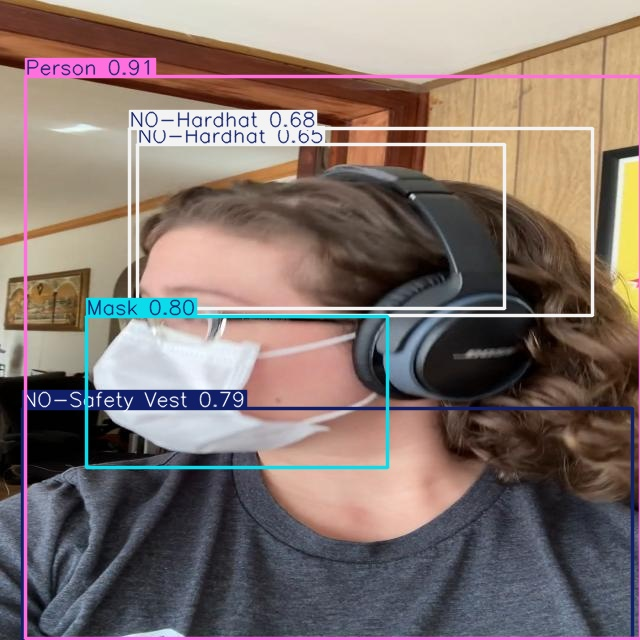

In [37]:
# ============================================================
# SHOW DETECTION RESULTS
# ============================================================
prediction_folder = "/kaggle/working/runs/detect/predict"

if os.path.exists(prediction_folder):
    files = [f for f in os.listdir(prediction_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Total Prediction Images: {len(files)}")
    print("First 5 files:", files[:5])
    
    if files:
        display(Image(filename=f"{prediction_folder}/{files[0]}"))
    else:
        print("No output images found to display.")
else:
    print(f"Prediction folder not found at: {prediction_folder}")

In [39]:
# ============================================================
# ZIP AND PREPARE TEST PREDICTIONS FOR DOWNLOAD
# ============================================================
import os
import zipfile

# Source directory containing your 82 predicted images
source_dir = "/kaggle/working/runs/detect/predict"
# Output destination path for the zip file
zip_output_path = "/kaggle/working/construction_safety_predictions.zip"

if os.path.exists(source_dir):
    files_to_zip = [f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if files_to_zip:
        print(f"Archiving {len(files_to_zip)} prediction images...")
        
        # Create the zip archive
        with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file in files_to_zip:
                file_path = os.path.join(source_dir, file)
                # arcname ensures files aren't nested deep inside runs/detect/predict folders inside the zip
                zipf.write(file_path, arcname=file)
                
        print(f"📊 Success! Archive created at: {zip_output_path}")
        print("👉 Refresh your right-hand file menu in Kaggle, look under '/kaggle/working', and click Download.")
    else:
        print(f"⚠️ No image files found to archive inside: {source_dir}")
else:
    print(f"⚠️ Target prediction directory not found: {source_dir}")

Archiving 82 prediction images...
📊 Success! Archive created at: /kaggle/working/construction_safety_predictions.zip
👉 Refresh your right-hand file menu in Kaggle, look under '/kaggle/working', and click Download.


In [40]:
# ============================================================
# SAFETY REPORT GENERATOR
# ============================================================
def generate_safety_report(detection_counts):
    no_helmet = detection_counts.get("NO-Hardhat", 0)
    no_vest = detection_counts.get("NO-Safety Vest", 0)
    no_mask = detection_counts.get("NO-Mask", 0)
    workers = detection_counts.get("Person", 0)

    total_violations = no_helmet + no_vest + no_mask

    if total_violations == 0:
        risk = "LOW"
    elif total_violations <= 2:
        risk = "MEDIUM"
    else:
        risk = "HIGH"

    report = f"""
===========================================
CONSTRUCTION SITE SAFETY REPORT
===========================================

Workers Detected: {workers}

SAFETY VIOLATIONS:
- No Hardhat: {no_helmet}
- No Safety Vest: {no_vest}
- No Mask: {no_mask}

TOTAL VIOLATIONS: {total_violations}

RISK LEVEL: {risk}

RECOMMENDATION:
Ensure all workers comply with PPE regulations
before continuing construction operations.

===========================================
"""
    return report

In [41]:
# ============================================================
# SAMPLE REPORT TESTING
# ============================================================
sample_counts = {
    "Person": 5,
    "NO-Hardhat": 2,
    "NO-Safety Vest": 1,
    "NO-Mask": 0
}

print(generate_safety_report(sample_counts))


CONSTRUCTION SITE SAFETY REPORT

Workers Detected: 5

SAFETY VIOLATIONS:
- No Hardhat: 2
- No Safety Vest: 1
- No Mask: 0

TOTAL VIOLATIONS: 3

RISK LEVEL: HIGH

RECOMMENDATION:
Ensure all workers comply with PPE regulations
before continuing construction operations.




In [42]:
# ============================================================
# SUMMARY INFO
# ============================================================
print("""
==================================================

WORKFLOW READY!

Real-time training metric figures, 
confusion matrix diagrams, and prediction bounding boxes 
all stored natively inside your working path folder:

/kaggle/working/construction_safety_project/

==================================================
""")



WORKFLOW READY!

Real-time training metric figures, 
confusion matrix diagrams, and prediction bounding boxes 
all stored natively inside your working path folder:

/kaggle/working/construction_safety_project/




In [44]:
# ============================================================
# EXACT DIRECT PATH ZIP FOR MODEL DOWNLOAD
# ============================================================
import os
import zipfile

# Direct path to your 50-epoch optimized run folder
model_weights_path = "/kaggle/working/runs/detect/construction_safety_project/yolov8s_run-5/weights/best.pt"
model_zip_output = "/kaggle/working/yolov8s_best_model.zip"

if os.path.exists(model_weights_path):
    print(f"Found best model weights at: {model_weights_path}")
    print("Archiving model weights...")
    
    with zipfile.ZipFile(model_zip_output, 'w', zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(model_weights_path, arcname="best.pt")
            
    print(f"\n📊 Success! Model archive created at: {model_zip_output}")
    print("👉 Refresh your right-hand file menu in Kaggle, look under '/kaggle/working', and download 'yolov8s_best_model.zip'.")
else:
    print(f"⚠️ Could not find 'best.pt' at: {model_weights_path}")

Found best model weights at: /kaggle/working/runs/detect/construction_safety_project/yolov8s_run-5/weights/best.pt
Archiving model weights...

📊 Success! Model archive created at: /kaggle/working/yolov8s_best_model.zip
👉 Refresh your right-hand file menu in Kaggle, look under '/kaggle/working', and download 'yolov8s_best_model.zip'.
